In [82]:
import numpy as np
import matplotlib.pyplot as plt
from math import factorial

## Задание №1

In [83]:
# Параметры
lambda_val = 0.1  # заявок/мс
Tk = 100          # время наблюдения (мс)
experiments = 10

results = []
all_interarrival_times = []

for exp in range(experiments):
    t = 0
    arrival_times = []
    interarrival_times = []
    
    while t < Tk:
        P = np.random.rand()
        delta_t = -(1/lambda_val) * np.log(P)
        t += delta_t
        
        if t < Tk:
            arrival_times.append(t)
            interarrival_times.append(delta_t)
    
    results.append(len(arrival_times))
    all_interarrival_times.extend(interarrival_times)
    
    print(f"Эксперимент {exp+1}: число заявок = {len(arrival_times)}")

mean_requests = np.mean(results)
mean_interarrival = np.mean(all_interarrival_times)

print("\nСреднее число заявок:", mean_requests)
print("Среднее время между заявками:", mean_interarrival)
# Среднее число заявок должно быть примерно E[N] = λT = 0.1×100 = 10
# Среднее время между заявками должно быть 1/λ = 10 мс

Эксперимент 1: число заявок = 9
Эксперимент 2: число заявок = 10
Эксперимент 3: число заявок = 9
Эксперимент 4: число заявок = 8
Эксперимент 5: число заявок = 12
Эксперимент 6: число заявок = 10
Эксперимент 7: число заявок = 13
Эксперимент 8: число заявок = 11
Эксперимент 9: число заявок = 8
Эксперимент 10: число заявок = 9

Среднее число заявок: 9.9
Среднее время между заявками: 9.447563113008592


## Задание №2

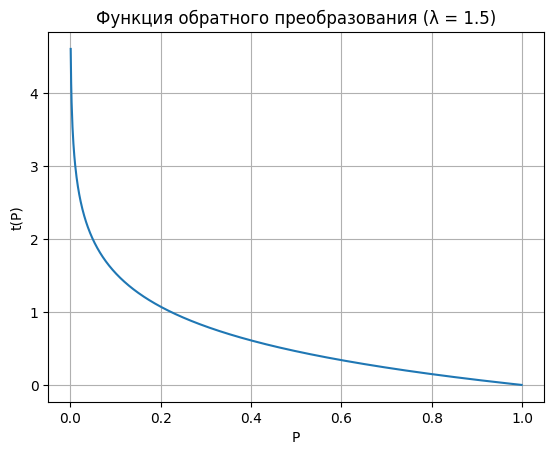

In [84]:
lambda_inv = 1.5

P = np.linspace(0.001, 0.999, 1000)
t_values = -(1/lambda_inv) * np.log(P)

plt.figure()
plt.plot(P, t_values)
plt.title("Функция обратного преобразования (λ = 1.5)")
plt.xlabel("P")
plt.ylabel("t(P)")
plt.grid()
plt.show()
# Экспоненциальное распределение

In [85]:
def generate_exponential(lambda_val, N):
    P = np.random.rand(N)
    return -(1/lambda_val) * np.log(P)

lambda_exp = 1.5
Ns = [10**3, 10**4, 10**5, 10**6]

generated_samples = {}

for N in Ns:
    samples = generate_exponential(lambda_exp, N)
    generated_samples[N] = samples
    print(f"N = {N}, среднее = {np.mean(samples):.5f}")
# Среднее значение должно стремиться к 1/λ = 1/1.5 ≈ 0.66667

N = 1000, среднее = 0.68891
N = 10000, среднее = 0.66671
N = 100000, среднее = 0.66894
N = 1000000, среднее = 0.66697


## Задание №3

N = 1000, Среднеквадратическое отклонение = 0.00281533


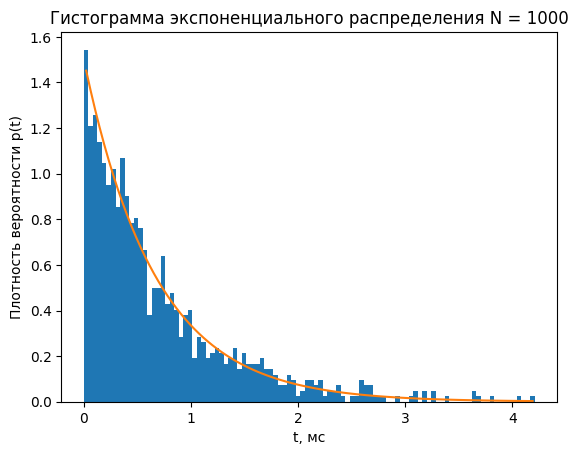

N = 10000, Среднеквадратическое отклонение = 0.00013287


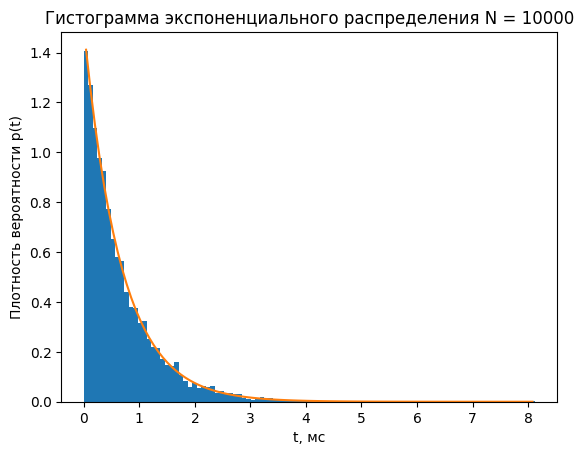

N = 100000, Среднеквадратическое отклонение = 0.00001115


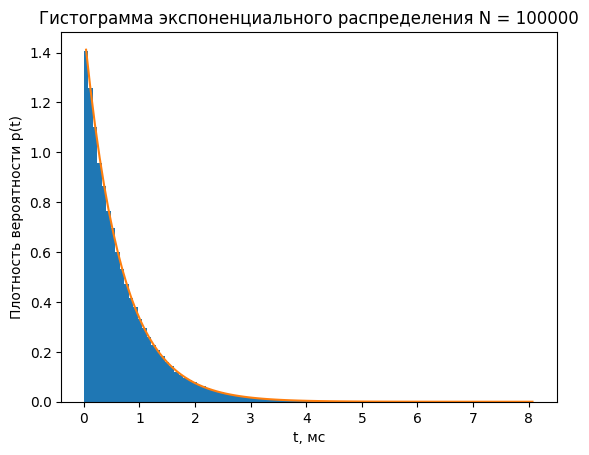

N = 1000000, Среднеквадратическое отклонение = 0.00000068


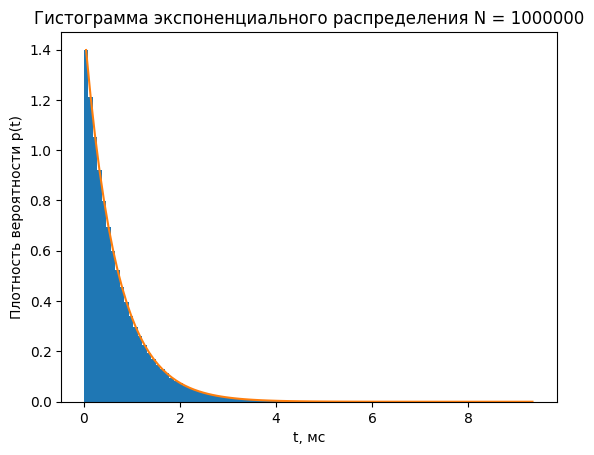

In [86]:
def theoretical_pdf(t, lambda_val):
    return lambda_val * np.exp(-lambda_val * t)

lambda_exp = 1.5

for N in Ns:
    samples = generated_samples[N]
    
    counts, bins = np.histogram(samples, bins=100, density=True)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    
    pdf_values = theoretical_pdf(bin_centers, lambda_exp)
    
    mse = np.mean((counts - pdf_values)**2)
    
    print(f"N = {N}, Среднеквадратическое отклонение = {mse:.8f}")
    
    plt.figure()
    plt.hist(samples, bins=100, density=True)
    plt.plot(bin_centers, pdf_values)
    plt.xlabel("t, мс")
    plt.ylabel("Плотность вероятности p(t)")
    plt.title(f"Гистограмма экспоненциального распределения N = {N}")
    plt.show()

## Задание №4

In [87]:
# 1
mu1 = 1
mu2 = 0.5
N = 60

def generate_exp_process(mu, N):
    P = np.random.rand(N)
    return -(1/mu) * np.log(P)

proc1 = generate_exp_process(mu1, N)
proc2 = generate_exp_process(mu2, N)

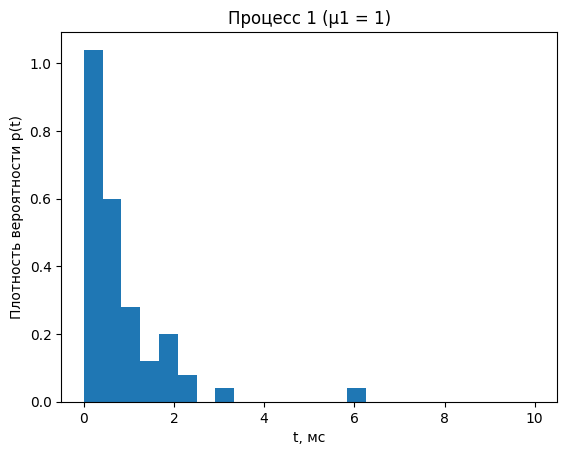

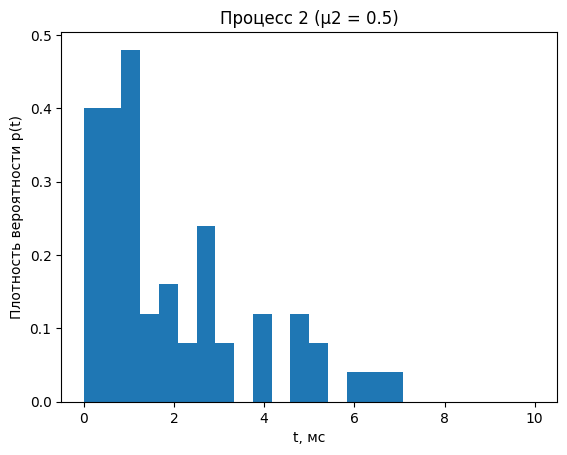

Площадь гистограммы 1: 1.0
Площадь гистограммы 2: 1.0


In [88]:
# 2
bins = 24
range_interval = (0, 10)

plt.figure()
counts1, bins1, _ = plt.hist(proc1, bins=bins, range=range_interval, density=True)
plt.xlabel("t, мс")
plt.ylabel("Плотность вероятности p(t)")
plt.title("Процесс 1 (μ1 = 1)")
plt.show()

plt.figure()
counts2, bins2, _ = plt.hist(proc2, bins=bins, range=range_interval, density=True)
plt.xlabel("t, мс")
plt.ylabel("Плотность вероятности p(t)")
plt.title("Процесс 2 (μ2 = 0.5)")
plt.show()

# Проверка площадей
area1 = np.sum(counts1 * (bins1[1]-bins1[0]))
area2 = np.sum(counts2 * (bins2[1]-bins2[0]))

print("Площадь гистограммы 1:", area1)
print("Площадь гистограммы 2:", area2)

In [89]:
# 3-5
m = 60
Tp_sum = []

# строим накопленные вероятности
prob1 = counts1 * (bins1[1] - bins1[0])
prob2 = counts2 * (bins2[1] - bins2[0])

cdf1 = np.cumsum(prob1)
cdf2 = np.cumsum(prob2)

for _ in range(m):
    p = np.random.rand()
    
    idx1 = np.searchsorted(cdf1, p)
    idx2 = np.searchsorted(cdf2, p)
    
    Tp1 = (bins1[idx1] + bins1[idx1+1]) / 2
    Tp2 = (bins2[idx2] + bins2[idx2+1]) / 2
    
    Tp_sum.append(Tp1 + Tp2)

Tp_sum = np.array(Tp_sum)

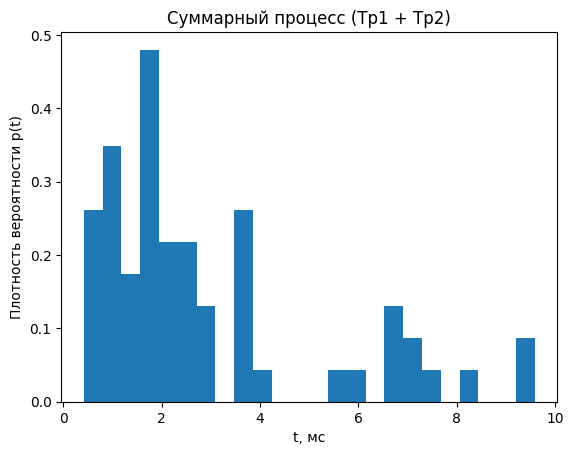

In [90]:
# 6
plt.figure()
plt.hist(Tp_sum, bins=24, density=True)
plt.xlabel("t, мс")
plt.ylabel("Плотность вероятности p(t)")
plt.title("Суммарный процесс (Tp1 + Tp2)")
plt.show()

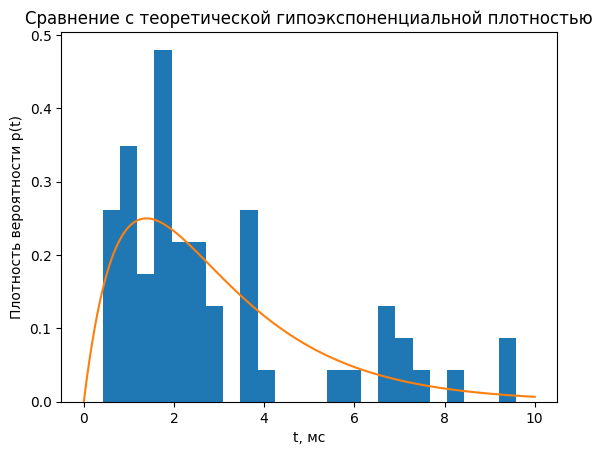

In [91]:
# 7
def hypo_pdf(t, mu1, mu2):
    return (mu1*mu2/(mu2-mu1)) * (np.exp(-mu1*t) - np.exp(-mu2*t))

t_vals = np.linspace(0, 10, 1000)

plt.figure()
plt.hist(Tp_sum, bins=24, density=True)
plt.plot(t_vals, hypo_pdf(t_vals, mu1, mu2))
plt.xlabel("t, мс")
plt.ylabel("Плотность вероятности p(t)")
plt.title("Сравнение с теоретической гипоэкспоненциальной плотностью")
plt.show()
# Гипоэкспоненциальное распределение (сумма нескольких экспоненциальных распределений с разными параметрами)